In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/marcosroquerosa/datasets/refs/heads/main/filmes_bilheteria/filmes_tratados.csv")

# Garantir tipos numéricos
cols = ['IMDb Rating', 'Runtime (mins)', 'Num Votes', 'Bilheteria', 'Bilheteria_por_minuto', 'Ano_Lancamento']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Remover nulos
df = df.dropna(subset=cols)

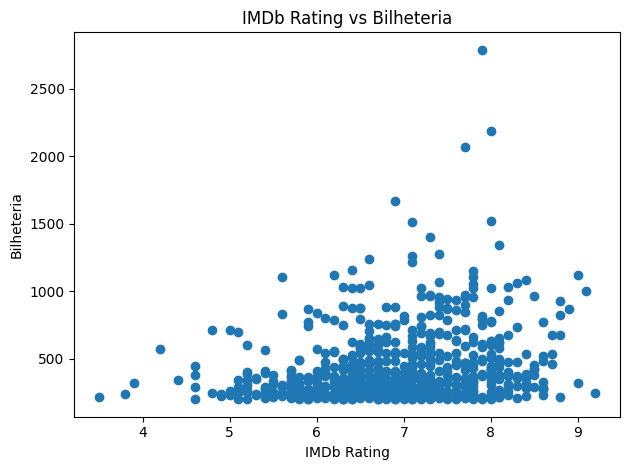

In [23]:
# Gráfico de dispersão (Rating vs Bilheteria)
# Pergunta: filmes melhores ganham mais dinheiro?
plt.figure()
plt.scatter(df['IMDb Rating'], df['Bilheteria'])

plt.title('IMDb Rating vs Bilheteria')
plt.xlabel('IMDb Rating')
plt.ylabel('Bilheteria')

plt.tight_layout()
plt.show()

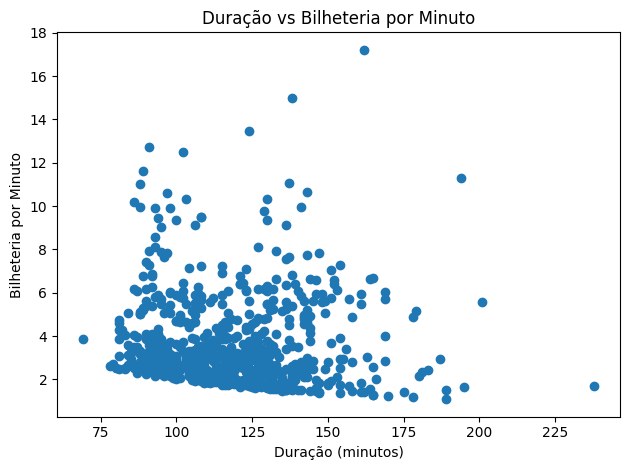

In [24]:
# Gráfico de dispersão (Runtime vs Bilheteria por minuto)
# Pergunta: filmes mais longos são menos eficientes?
plt.figure()
plt.scatter(df['Runtime (mins)'], df['Bilheteria_por_minuto'])

plt.title('Duração vs Bilheteria por Minuto')
plt.xlabel('Duração (minutos)')
plt.ylabel('Bilheteria por Minuto')

plt.tight_layout()
plt.show()

In [25]:
# Matriz de correlação
# Rating vs Bilheteria - Correlação fraca → qualidade ≠ sucesso financeiro
# Votes vs Bilheteria - Geralmente forte → popularidade
# Runtime - Normalmente pouca influência

df[[
    'IMDb Rating',
    'Runtime (mins)',
    'Num Votes',
    'Bilheteria',
    'Bilheteria_por_minuto',
    'Ano_Lancamento'
]].corr()

,IMDb Rating,Runtime (mins),Num Votes,Bilheteria,Bilheteria_por_minuto,Ano_Lancamento
IMDb Rating,1.000000,0.357722,0.691593,0.235647,0.155015,-0.217134
Runtime (mins),0.357722,1.000000,0.424301,0.267857,-0.048970,-0.051056
Num Votes,0.691593,0.424301,1.000000,0.413772,0.289435,-0.041284
Bilheteria,0.235647,0.267857,0.413772,1.000000,0.927839,0.185627
Bilheteria_por_minuto,0.155015,-0.048970,0.289435,0.927839,1.000000,0.203111
Ano_Lancamento,-0.217134,-0.051056,-0.041284,0.185627,0.203111,1.000000


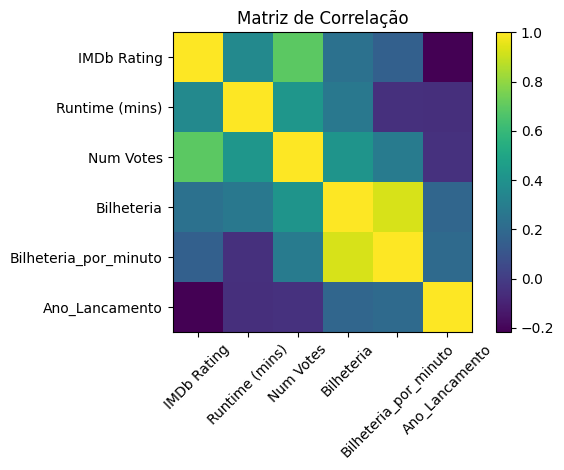

In [26]:
# Visualização da correlação (heatmap simples com matplotlib)
plt.figure()
plt.imshow(corr, interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Matriz de Correlação')

plt.tight_layout()
plt.show()

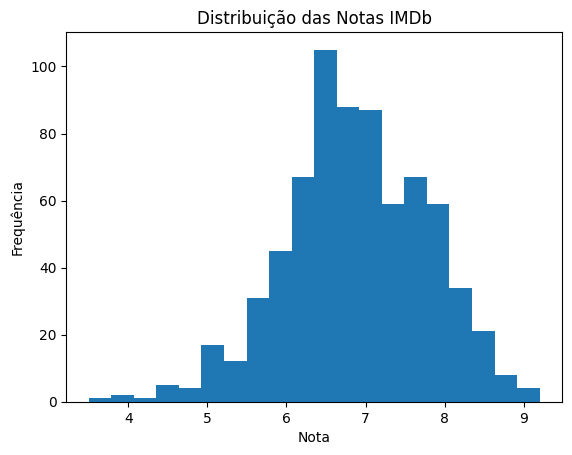

In [27]:
# Distribuição das notas IMDb (histograma)
# Pergunta: os filmes são concentrados em notas medianas ou extremos?

import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['IMDb Rating'], bins=20)

plt.title('Distribuição das Notas IMDb')
plt.xlabel('Nota')
plt.ylabel('Frequência')

plt.show()

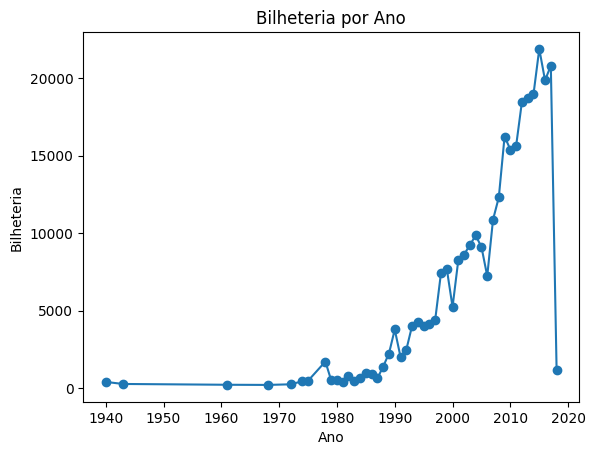

In [28]:
# Receita por ano (tendência temporal)
# Pergunta: o mercado está crescendo?
receita_ano = df.groupby('Ano_Lancamento')['Bilheteria'].sum()

plt.figure()
plt.plot(receita_ano.index, receita_ano.values, marker='o')

plt.title('Bilheteria por Ano')
plt.xlabel('Ano')
plt.ylabel('Bilheteria')

plt.show()

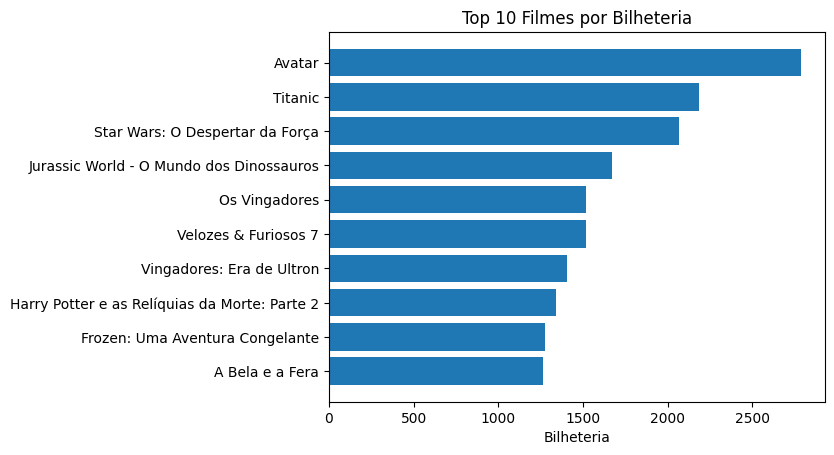

In [29]:
# Top 10 filmes por bilheteria (barras)
# Pergunta: quem domina financeiramente?

top_filmes = df.sort_values('Bilheteria', ascending=False).head(10)

plt.figure()
plt.barh(top_filmes['Title'], top_filmes['Bilheteria'])

plt.title('Top 10 Filmes por Bilheteria')
plt.xlabel('Bilheteria')

plt.gca().invert_yaxis()
plt.show()

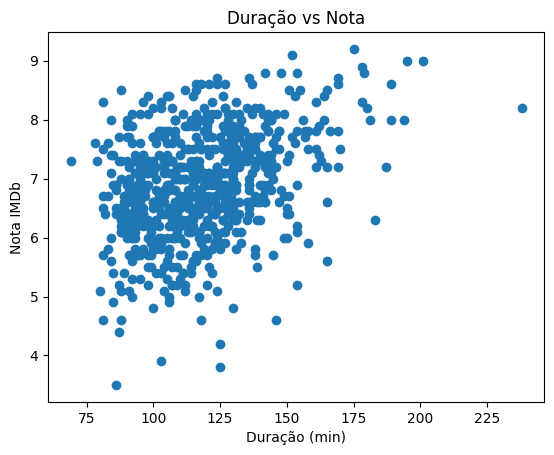

In [30]:
# Duração vs Nota (vale a pena filme longo?)
plt.figure()
plt.scatter(df['Runtime (mins)'], df['IMDb Rating'])

plt.title('Duração vs Nota')
plt.xlabel('Duração (min)')
plt.ylabel('Nota IMDb')

plt.show()